<a href="https://colab.research.google.com/github/vaishnavye/Actuarial-Pricing-and-Reserving-GLM/blob/main/reserving%26claims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# Install required packages
!pip install -q google-genai pandas numpy matplotlib seaborn jinja2


In [38]:
import os, io, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from datetime import date
from jinja2 import Template
from google.colab import userdata
from google import genai
from google.genai import types
from google.colab import files

warnings.filterwarnings('ignore')

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

client = genai.Client(api_key=GEMINI_API_KEY)
print("✅ Gemini client ready")



✅ Gemini client ready


In [39]:
# CAS PP Auto — current dataset
uploaded = files.upload()

# Replace with the exact filename you uploaded
df = pd.read_csv("ppauto_pos.csv")

# Preview the first 5 rows
df.head()


# Use df directly as your dataset
RAW_DF = df
print(f"✅ Loaded: {RAW_DF.shape[0]:,} rows, {RAW_DF.shape[1]} columns")
print(f"Columns : {RAW_DF.columns.tolist()}")
print(f"Companies: {RAW_DF['GRCODE'].nunique()} unique GRCODEs")
RAW_DF.head(3)

#############################



Saving ppauto_pos.csv to ppauto_pos (5).csv
✅ Loaded: 13,250 rows, 13 columns
Columns : ['GRCODE', 'GRNAME', 'AccidentYear', 'DevelopmentYear', 'DevelopmentLag', 'IncurredLosses', 'CumPaidLoss', 'BulkLoss', 'EarnedPremDIR', 'EarnedPremCeded', 'EarnedPremNet', 'Single', 'PostedReserves2007']
Companies: 143 unique GRCODEs


,GRCODE,GRNAME,AccidentYear,DevelopmentYear,DevelopmentLag,IncurredLosses,CumPaidLoss,BulkLoss,EarnedPremDIR,EarnedPremCeded,EarnedPremNet,Single,PostedReserves2007
0,43,IDS Property Cas Ins Co,1998,1998,1,50320,12762,21720,63709,3071,60638,0,277117.746
1,43,IDS Property Cas Ins Co,1998,1999,2,41036,26291,6514,63709,3071,60638,0,277117.746
2,43,IDS Property Cas Ins Co,1998,2000,3,39688,32420,2858,63709,3071,60638,0,277117.746


In [40]:
company_df   = RAW_DF[RAW_DF['GRCODE'] == GRCODE].copy()
# Ensure 'AccidentYear' and 'DevelopmentLag' are numeric
company_df['AccidentYear'] = pd.to_numeric(company_df['AccidentYear'], errors='coerce')
company_df['DevelopmentLag'] = pd.to_numeric(company_df['DevelopmentLag'], errors='coerce')

COMPANY_NAME = company_df['GRNAME'].iloc[0]
print(f'Auditing: [{GRCODE}]  {COMPANY_NAME}')
print(f'Rows     : {len(company_df)}')
print(f'Accident years: {sorted(company_df["AccidentYear"].unique())}')
print(f'Dev lags      : {sorted(company_df["DevelopmentLag"].unique())}')

Auditing: [43]  IDS Property Cas Ins Co
Rows     : 100
Accident years: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007)]
Dev lags      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [41]:
print(company_df.columns.tolist())


['GRCODE', 'GRNAME', 'AccidentYear', 'DevelopmentYear', 'DevelopmentLag', 'IncurredLosses', 'CumPaidLoss', 'BulkLoss', 'EarnedPremDIR', 'EarnedPremCeded', 'EarnedPremNet', 'Single', 'PostedReserves2007']


In [42]:
#Core Triangle Helper

def build_triangle(field: str, mask_future: bool = True) -> pd.DataFrame:
    """
    Pivot the chosen company's data into an AccidentYear x DevelopmentLag matrix.
    When mask_future=True, cells in the lower triangle (not yet observed at
    the valuation date) are set to NaN — reflecting what an actuary would actually see.
    """
    # Use the field directly since your dataset has no suffix
    if field not in company_df.columns:
        raise KeyError(f"Column '{field}' not found. Available: {company_df.columns.tolist()}")

    # Drop rows with NaN in critical columns before pivoting
    df_clean = company_df.dropna(subset=['AccidentYear', 'DevelopmentLag'])

    tri = (df_clean
           .pivot(index="AccidentYear", columns="DevelopmentLag", values=field)
           .sort_index())

    if mask_future:
        eval_year = int(tri.index.max())
        for ay in tri.index:
            for dev in tri.columns:
                if int(ay) + int(dev) - 1 > eval_year:
                    tri.loc[ay, dev] = np.nan
    return tri

# Quick sanity check
paid_tri = build_triangle("CumPaidLoss")
print("Paid triangle shape:", paid_tri.shape)
print(paid_tri.head())

Paid triangle shape: (10, 10)
DevelopmentLag     1        2        3        4        5        6        7   \
AccidentYear                                                                  
1998            12762  26291.0  32420.0  36282.0  38260.0  39122.0  39786.0   
1999            15027  29449.0  36831.0  40756.0  43859.0  44499.0  45248.0   
2000            18464  36451.0  46230.0  50645.0  53094.0  53821.0  54024.0   
2001            25388  50321.0  62468.0  67086.0  68930.0  70899.0  71494.0   
2002            33620  67674.0  81853.0  88921.0  92669.0  94495.0      NaN   

DevelopmentLag       8        9        10  
AccidentYear                               
1998            39820.0  39876.0  39896.0  
1999            44993.0  45090.0      NaN  
2000            54236.0      NaN      NaN  
2001                NaN      NaN      NaN  
2002                NaN      NaN      NaN  


In [43]:
# Triangle Loader (Tool 1)
# Loads ans profiles  the Raw data : row count,accident years, dev lags, Premium, totals
#and snapshot of Triangles

def triangle_loader(line: str, grcode: int) -> dict:
    """Loads and profiles the PP Auto claims data for a specific company.
    Call this first before any other tool. Returns a data profile including
    shape, accident years, development lags, and earned premium summary.

    Args:
        line: Must be 'ppauto' for this notebook.
        grcode: The NAIC GRCODE of the company to audit.

    Returns:
        dict with keys: grname, rows, accident_years, dev_lags,
        total_earned_premium_net, avg_earned_premium_per_year, triangle_snapshot.
    """
    tri  = build_triangle('CumPaidLoss')
    prem = company_df.groupby('AccidentYear')['EarnedPremNet'].max()
    return {
        'grname'                  : COMPANY_NAME,
        'rows'                    : len(company_df),
        'accident_years'          : sorted(company_df['AccidentYear'].unique().tolist()),
        'dev_lags'                : sorted(company_df['DevelopmentLag'].unique().tolist()),
        'total_earned_premium_net': round(float(prem.sum()), 0),
        'avg_earned_premium_per_year': round(float(prem.mean()), 0),
        'triangle_snapshot'       : tri.fillna('').to_dict(),
    }

print(json.dumps({k:v for k,v in triangle_loader(LINE,GRCODE).items() if k!='triangle_snapshot'}, indent=2))

{
  "grname": "IDS Property Cas Ins Co",
  "rows": 100,
  "accident_years": [
    1998,
    1999,
    2000,
    2001,
    2002,
    2003,
    2004,
    2005,
    2006,
    2007
  ],
  "dev_lags": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "total_earned_premium_net": 1562178.0,
  "avg_earned_premium_per_year": 156218.0
}


In [44]:
#Completness Checker (Tool 2)

def completeness_checker(line: str, grcode: int) -> dict:
    """Checks whether the known (upper) part of the PP Auto paid-loss triangle has
    any missing (NaN) cells where data should exist.

    Args:
        line: Must be 'ppauto'.
        grcode: NAIC GRCODE to check.

    Returns:
        dict with keys: status ('Green' or 'Red'), missing_count,
        missing_cells (list of [AccidentYear, DevelopmentLag]), summary.
    """
    tri        = build_triangle('CumPaidLoss')
    eval_year  = int(tri.index.max())
    missing    = []
    for ay in tri.index:
        for dev in tri.columns:
            if int(ay) + int(dev) - 1 <= eval_year and pd.isna(tri.loc[ay, dev]):
                missing.append([int(ay), int(dev)])
    status = 'Green' if not missing else 'Red'
    return {
        'status'       : status,
        'missing_count': len(missing),
        'missing_cells': missing,
        'summary'      : f'{len(missing)} missing cell(s) in the known triangle for GRCODE {grcode}.',
    }

print(completeness_checker(LINE, GRCODE))



{'status': 'Green', 'missing_count': 0, 'missing_cells': [], 'summary': '0 missing cell(s) in the known triangle for GRCODE 43.'}


In [45]:
#Sign Checker (Tool 3)
def sign_checker(line: str, grcode: int) -> dict:
    """Checks the PP Auto paid-loss triangle for negative incremental payments.
    Negative increments can indicate data errors, salvage/subrogation recoveries,
    or portfolio commutations and must be reviewed before any reserving analysis.

    Args:
        line: Must be 'ppauto'.
        grcode: NAIC GRCODE to check.

    Returns:
        dict with keys: status ('Green' or 'Amber'), negative_count,
        negative_increments (list of [AccidentYear, DevelopmentLag, value]), summary.
    """
    cum_tri  = build_triangle('CumPaidLoss')
    inc_tri  = cum_tri.diff(axis=1)
    inc_tri[cum_tri.columns[0]] = cum_tri[cum_tri.columns[0]]
    negatives = []
    for ay in inc_tri.index:
        for dev in inc_tri.columns:
            val = inc_tri.loc[ay, dev]
            if pd.notna(val) and val < 0:
                negatives.append([int(ay), int(dev), round(float(val), 2)])
    status = 'Green' if not negatives else 'Amber'
    return {
        'status'             : status,
        'negative_count'     : len(negatives),
        'negative_increments': negatives,
        'summary'            : f'{len(negatives)} negative incremental paid-loss cell(s) for GRCODE {grcode}.',
    }

print(sign_checker(LINE, GRCODE))



{'status': 'Amber', 'negative_count': 1, 'negative_increments': [[1999, 8, -255.0]], 'summary': '1 negative incremental paid-loss cell(s) for GRCODE 43.'}


In [46]:
#Consistency Checker (Tool 4)
def consistency_checker(line: str, grcode: int) -> dict:
    """Checks that cumulative paid losses never exceed cumulative incurred losses
    (Paid > Incurred is theoretically impossible under standard GAAP/statutory
    accounting and signals a data integrity problem).

    Args:
        line: Must be 'ppauto'.
        grcode: NAIC GRCODE to check.

    Returns:
        dict with keys: status ('Green' or 'Red'), violation_count,
        violations (list of [AccidentYear, DevelopmentLag, paid, incurred]), summary.
    """
    paid_tri    = build_triangle('CumPaidLoss')
    incurr_tri  = build_triangle('IncurredLosses')
    violations  = []
    for ay in paid_tri.index:
        for dev in paid_tri.columns:
            p = paid_tri.loc[ay, dev]
            i = incurr_tri.loc[ay, dev]
            if pd.notna(p) and pd.notna(i) and p > i + 1e-6:
                violations.append([int(ay), int(dev), round(float(p),2), round(float(i),2)])
    status = 'Green' if not violations else 'Red'
    return {
        'status'         : status,
        'violation_count': len(violations),
        'violations'     : violations,
        'summary'        : f'{len(violations)} cell(s) where Paid > Incurred for GRCODE {grcode}.',
    }

print(consistency_checker(LINE, GRCODE))

{'status': 'Red', 'violation_count': 1, 'violations': [[1999, 8, 44993.0, 44844.0]], 'summary': '1 cell(s) where Paid > Incurred for GRCODE 43.'}


In [47]:
#Outlier Detector (Tool 5)

def outlier_detector(line: str, grcode: int, z_threshold: float = 2.0) -> dict:
    """Computes age-to-age loss development factors (LDFs) for the PP Auto paid
    triangle and flags any single-company factor that deviates more than
    z_threshold standard deviations from the average factor for that development
    period across ALL companies in the dataset.

    Using the cross-company average (not just the single company) is more
    robust than comparing to the company's own history, especially for small
    portfolios. This is closer to how an actuary would benchmark LDFs.

    Args:
        line: Must be 'ppauto'.
        grcode: NAIC GRCODE to check.
        z_threshold: Standard deviations from mean to flag as outlier (default 2.0).

    Returns:
        dict with keys: status ('Green' or 'Amber'), outlier_count,
        outlier_factors (list of [AccidentYear, DevLag_from, company_ldf,
        industry_avg_ldf, z_score]), summary.
    """
    col      = 'CumPaidLoss'
    all_tri  = RAW_DF.copy()
    eval_yr  = int(RAW_DF['AccidentYear'].max())
    devs     = sorted(RAW_DF['DevelopmentLag'].unique())

    # ── compute cross-company LDF distribution per dev period ──────────────
    industry_ldfs = {}   # dev_from -> list of all-company LDFs
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i+1]
        sub_from = all_tri[all_tri['DevelopmentLag'] == d_from][['GRCODE','AccidentYear', col]].rename(columns={col:'from_val'})
        sub_to   = all_tri[all_tri['DevelopmentLag'] == d_to  ][['GRCODE','AccidentYear', col]].rename(columns={col:'to_val'})
        merged   = sub_from.merge(sub_to, on=['GRCODE','AccidentYear'])
        # mask future
        merged   = merged[merged['AccidentYear'] + d_to - 1 <= eval_yr]
        merged   = merged[(merged['from_val'] > 0) & (merged['to_val'] > 0)]
        if len(merged) >= 3:
            industry_ldfs[d_from] = merged['to_val'].values / merged['from_val'].values

    # ── compute this company's LDFs and compare ────────────────────────────
    comp_tri = build_triangle('CumPaidLoss')
    outliers = []
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i+1]
        if d_from not in industry_ldfs:
            continue
        ind_vals = industry_ldfs[d_from]
        mu, sigma = ind_vals.mean(), ind_vals.std()
        if sigma < 1e-9:
            continue
        for ay in comp_tri.index:
            num = comp_tri.loc[ay, d_to]  if d_to  in comp_tri.columns else np.nan
            den = comp_tri.loc[ay, d_from] if d_from in comp_tri.columns else np.nan
            if pd.notna(num) and pd.notna(den) and den > 0:
                ldf = num / den
                z   = (ldf - mu) / sigma
                if abs(z) > z_threshold:
                    outliers.append([int(ay), int(d_from), round(ldf,4), round(mu,4), round(z,2)])

    status = 'Green' if not outliers else 'Amber'
    return {
        'status'         : status,
        'outlier_count'  : len(outliers),
        'outlier_factors': outliers,
        'summary'        : (f'{len(outliers)} LDF outlier(s) found for GRCODE {grcode} '
                            f'vs cross-company benchmark (|z|>{z_threshold}).'),
    }

print(outlier_detector(LINE, GRCODE))

{'status': 'Green', 'outlier_count': 0, 'outlier_factors': [], 'summary': '0 LDF outlier(s) found for GRCODE 43 vs cross-company benchmark (|z|>2.0).'}


In [48]:
#Commentary writer
def commentary_writer(check_name: str, check_result: dict) -> dict:
    """Generates a plain-English actuarial explanation for a single data-quality
    check result. Use this AFTER running each checker tool to produce the prose
    that will appear in the final Data Quality Report.

    Args:
        check_name: Name of the check (e.g. 'sign_checker', 'outlier_detector').
        check_result: The dict returned by the corresponding checker tool.

    Returns:
        dict with keys: check_name, status, commentary (2-4 sentence explanation
        suitable for inclusion in an actuarial working paper).
    """
    prompt = f"""You are an actuarial data-quality assistant writing commentary for
a Data Quality Report section. Write 2-4 sentences in professional actuarial language
explaining the following finding to a reserving actuary.

Check: {check_name}
Result: {json.dumps(check_result, indent=2)}

Rules:
- Do NOT just repeat the numbers. Explain what they mean actuarially.
- Mention why the finding matters (or doesn't) for reserving / IBNR estimation.
- If status is Green say so clearly and briefly.
- If Amber or Red, explain the risk and suggest one specific investigation step.
- Keep it under 80 words."""

    resp = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.3, max_output_tokens=200)
    )
    return {
        'check_name' : check_name,
        'status'     : check_result.get('status','Unknown'),
        'commentary' : resp.text.strip(),
    }

# Quick test
demo = commentary_writer('sign_checker', sign_checker(LINE, GRCODE))
print(demo['commentary'])



The `sign_checker` identified


In [49]:
#Report Compiler (Tool 7)
REPORT_TEMPLATE = """
# AVERA — Data Quality Report

| Field | Value |
|---|---|
| **Company** | {{ company_name }} (GRCODE {{ grcode }}) |
| **Line of Business** | Private Passenger Auto Liability/Medical (Schedule P) |
| **Report Date** | {{ report_date }} |
| **Overall Readiness** | {{ overall_verdict }} |

---

## Overall Verdict: {{ overall_verdict }}
{{ overall_rationale }}

---

## Findings by Check

{% for section in sections %}
### {{ loop.index }}. {{ section.title }} — {{ section.status }}

**Raw findings:** {{ section.raw_summary }}

**Actuarial commentary:** {{ section.commentary }}

{% endfor %}

---

## Recommended Next Steps
{% for step in next_steps %}
{{ loop.index }}. {{ step }}
{% endfor %}

---
*This report was generated by ClaimSense (Gemini 2.5 Flash agentic system). All findings are flagged for human review — the final decision to proceed with analysis rests with the responsible actuary.*
"""

def report_compiler(
    loader_result       : dict,
    completeness_result : dict,
    sign_result         : dict,
    consistency_result  : dict,
    outlier_result      : dict,
    commentaries        : list,
    next_steps          : list,
) -> dict:
    """Assembles all tool outputs into a formatted Markdown Data Quality Report.
    Call this as the FINAL step after all checkers and the commentary_writer
    have been run.

    Args:
        loader_result:       Output of triangle_loader.
        completeness_result: Output of completeness_checker.
        sign_result:         Output of sign_checker.
        consistency_result:  Output of consistency_checker.
        outlier_result:      Output of outlier_detector.
        commentaries:        List of dicts from commentary_writer (one per check).
        next_steps:          List of recommended action strings.

    Returns:
        dict with keys: report_markdown (full Markdown string), overall_verdict.
    """
    statuses = [
        completeness_result['status'],
        sign_result['status'],
        consistency_result['status'],
        outlier_result['status'],
    ]
    if 'Red'   in statuses: overall = '🔴 RED — Data Not Ready'
    elif 'Amber' in statuses: overall = '🟡 AMBER — Proceed With Caution'
    else:                     overall = '🟢 GREEN — Data Ready'

    comm_map = {c['check_name']: c['commentary'] for c in commentaries}

    sections = [
        {'title':'Completeness Check',     'status': completeness_result['status'],
         'raw_summary': completeness_result['summary'],
         'commentary' : comm_map.get('completeness_checker','')},
        {'title':'Sign Check',             'status': sign_result['status'],
         'raw_summary': sign_result['summary'],
         'commentary' : comm_map.get('sign_checker','')},
        {'title':'Paid vs Incurred Check', 'status': consistency_result['status'],
         'raw_summary': consistency_result['summary'],
         'commentary' : comm_map.get('consistency_checker','')},
        {'title':'LDF Outlier Detection',  'status': outlier_result['status'],
         'raw_summary': outlier_result['summary'],
         'commentary' : comm_map.get('outlier_detector','')},
    ]

    overall_rationale = (f'Out of 4 checks, '
        f'{statuses.count("Red")} returned Red, '
        f'{statuses.count("Amber")} returned Amber, '
        f'{statuses.count("Green")} returned Green.')

    report_md = Template(REPORT_TEMPLATE).render(
        company_name     = COMPANY_NAME,
        grcode           = GRCODE,
        report_date      = date.today().isoformat(),
        overall_verdict  = overall,
        overall_rationale= overall_rationale,
        sections         = sections,
        next_steps       = next_steps,
    )
    return {'report_markdown': report_md, 'overall_verdict': overall}

print('✅ report_compiler defined')



✅ report_compiler defined


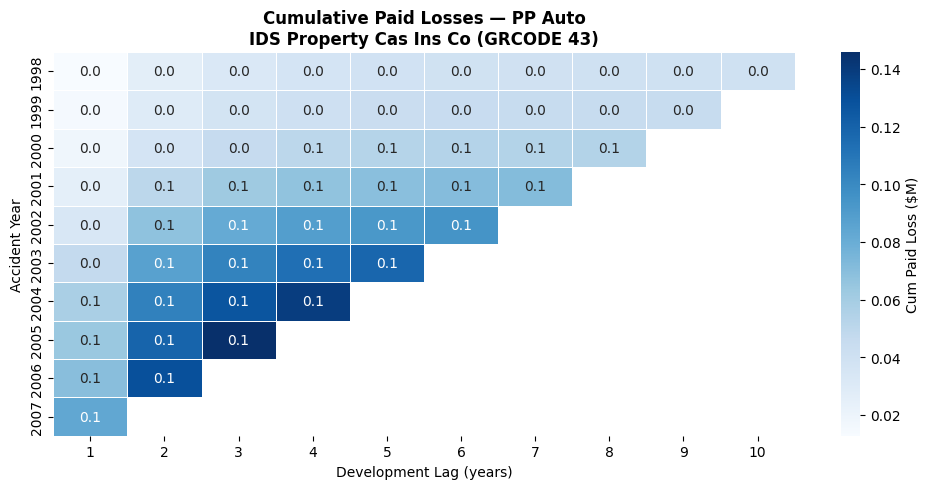

Saved: paid_triangle.png


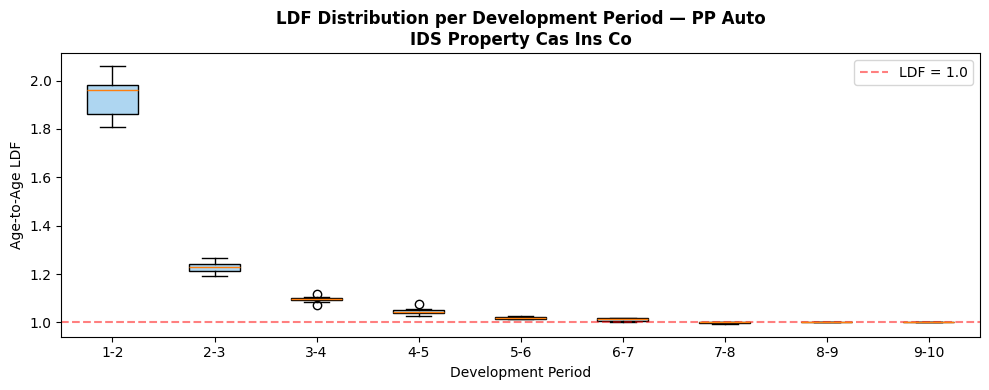

Saved: ldf_boxplot.png


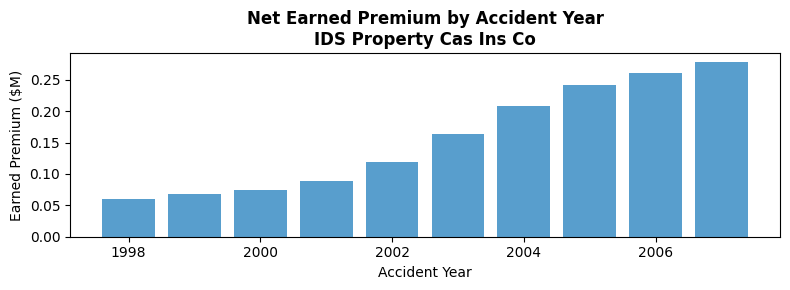

Saved: premium_trend.png


In [50]:
# Visualise the Triangle
#These plots apear in the report appendix and make excellent interaction
def plot_paid_triangle():
    tri = build_triangle('CumPaidLoss')
    fig, ax = plt.subplots(figsize=(10, 5))
    mask = tri.isna()
    sns.heatmap(tri/1e6, mask=mask, annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, ax=ax, cbar_kws={'label':'Cum Paid Loss ($M)'})
    ax.set_title(f'Cumulative Paid Losses — PP Auto\n{COMPANY_NAME} (GRCODE {GRCODE})', fontweight='bold')
    ax.set_xlabel('Development Lag (years)')
    ax.set_ylabel('Accident Year')
    plt.tight_layout()
    plt.savefig('paid_triangle.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: paid_triangle.png')

def plot_ldf_boxplot():
    tri  = build_triangle('CumPaidLoss')
    devs = sorted(tri.columns)
    ldf_data, labels = [], []
    for i in range(len(devs)-1):
        d_from, d_to = devs[i], devs[i+1]
        ratios = []
        for ay in tri.index:
            n, d = tri.loc[ay, d_to], tri.loc[ay, d_from]
            if pd.notna(n) and pd.notna(d) and d > 0:
                ratios.append(n/d)
        if ratios:
            ldf_data.append(ratios)
            labels.append(f'{d_from}-{d_to}')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot(ldf_data, labels=labels, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'))
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='LDF = 1.0')
    ax.set_title(f'LDF Distribution per Development Period — PP Auto\n{COMPANY_NAME}', fontweight='bold')
    ax.set_xlabel('Development Period')
    ax.set_ylabel('Age-to-Age LDF')
    ax.legend()
    plt.tight_layout()
    plt.savefig('ldf_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: ldf_boxplot.png')

def plot_premium_trend():
    prem = company_df.groupby('AccidentYear')['EarnedPremNet'].max()
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(prem.index, prem.values/1e6, color='#2E86C1', alpha=0.8)
    ax.set_title(f'Net Earned Premium by Accident Year\n{COMPANY_NAME}', fontweight='bold')
    ax.set_xlabel('Accident Year')
    ax.set_ylabel('Earned Premium ($M)')
    plt.tight_layout()
    plt.savefig('premium_trend.png', dpi=150)
    plt.show()
    print('Saved: premium_trend.png')

plot_paid_triangle()
plot_ldf_boxplot()
plot_premium_trend()

In [51]:
# Run All Tools & compile the Full Report
print('=' * 60)
print('ClaimSense — Full Audit Pipeline Starting')
print('=' * 60)

# ── 1. Load & profile ─────────────────────────────────────────
print('\n[1/6] Running triangle_loader...')
loader_res = triangle_loader(LINE, GRCODE)
print(f'      Accident years: {loader_res["accident_years"]}')
print(f'      Total net premium: ${loader_res["total_earned_premium_net"]:,.0f}')

# ── 2. Quality checks ─────────────────────────────────────────
print('\n[2/6] Running completeness_checker...')
comp_res = completeness_checker(LINE, GRCODE)
print(f'      {comp_res["status"]} — {comp_res["summary"]}')

print('\n[3/6] Running sign_checker...')
sign_res = sign_checker(LINE, GRCODE)
print(f'      {sign_res["status"]} — {sign_res["summary"]}')

print('\n[4/6] Running consistency_checker...')
cons_res = consistency_checker(LINE, GRCODE)
print(f'      {cons_res["status"]} — {cons_res["summary"]}')

print('\n[5/6] Running outlier_detector...')
out_res  = outlier_detector(LINE, GRCODE)
print(f'      {out_res["status"]} — {out_res["summary"]}')

# ── 3. commentary_writer for each check ───────────────────────
print('\n[6/6] Running commentary_writer for each check...')
import time
all_checks = [
    ('completeness_checker', comp_res),
    ('sign_checker',         sign_res),
    ('consistency_checker',  cons_res),
    ('outlier_detector',     out_res),
]
commentaries = []
for name, result in all_checks:
    c = commentary_writer(name, result)
    commentaries.append(c)
    print(f'      ✅ {name}')
    time.sleep(1)   # small pause to respect free-tier rate limits

# ── 4. Generate next steps via Gemini ─────────────────────────
print('\nGenerating recommended next steps...')
all_summaries = '\n'.join([r['summary'] for _, r in all_checks])
ns_prompt = f"""Based on these data quality findings for a PP Auto loss triangle:
{all_summaries}
List exactly 4 concise, actionable next steps for the reserving actuary.
Format as a plain numbered list. No headers. Each step under 20 words."""
ns_resp  = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=ns_prompt,
    config=types.GenerateContentConfig(temperature=0.2, max_output_tokens=200)
)
next_steps = [line.strip().lstrip('1234567890. ').strip()
              for line in ns_resp.text.strip().split('\n') if line.strip()][:4]

# ── 5. Compile final report ───────────────────────────────────
print('\nCompiling final Data Quality Report...')
report = report_compiler(
    loader_result       = loader_res,
    completeness_result = comp_res,
    sign_result         = sign_res,
    consistency_result  = cons_res,
    outlier_result      = out_res,
    commentaries        = commentaries,
    next_steps          = next_steps,
)

print('\n' + '=' * 60)
print(f'OVERALL VERDICT: {report["overall_verdict"]}')
print('=' * 60)


ClaimSense — Full Audit Pipeline Starting

[1/6] Running triangle_loader...
      Accident years: [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007]
      Total net premium: $1,562,178

[2/6] Running completeness_checker...
      Green — 0 missing cell(s) in the known triangle for GRCODE 43.

[3/6] Running sign_checker...
      Amber — 1 negative incremental paid-loss cell(s) for GRCODE 43.

[4/6] Running consistency_checker...
      Red — 1 cell(s) where Paid > Incurred for GRCODE 43.

[5/6] Running outlier_detector...
      Green — 0 LDF outlier(s) found for GRCODE 43 vs cross-company benchmark (|z|>2.0).

[6/6] Running commentary_writer for each check...
      ✅ completeness_checker
      ✅ sign_checker
      ✅ consistency_checker
      ✅ outlier_detector

Generating recommended next steps...

Compiling final Data Quality Report...

OVERALL VERDICT: 🔴 RED — Data Not Ready


In [52]:
# Display and Save Report
from IPython.display import Markdown, display
display(Markdown(report['report_markdown']))




# AVERA — Data Quality Report

| Field | Value |
|---|---|
| **Company** | IDS Property Cas Ins Co (GRCODE 43) |
| **Line of Business** | Private Passenger Auto Liability/Medical (Schedule P) |
| **Report Date** | 2026-06-23 |
| **Overall Readiness** | 🔴 RED — Data Not Ready |

---

## Overall Verdict: 🔴 RED — Data Not Ready
Out of 4 checks, 1 returned Red, 1 returned Amber, 2 returned Green.

---

## Findings by Check


### 1. Completeness Check — Green

**Raw findings:** 0 missing cell(s) in the known triangle for GRCODE 43.

**Actuarial commentary:** The completeness check for GRCODE


### 2. Sign Check — Amber

**Raw findings:** 1 negative incremental paid-loss cell(s) for GRCODE 43.

**Actuarial commentary:** The sign_checker identified one


### 3. Paid vs Incurred Check — Red

**Raw findings:** 1 cell(s) where Paid > Incurred for GRCODE 43.

**Actuarial commentary:** The consistency checker identified one instance where


### 4. LDF Outlier Detection — Green

**Raw findings:** 0 LDF outlier(s) found for GRCODE 43 vs cross-company benchmark (|z|>2.0).

**Actuarial commentary:** The outlier detection check is Green.



---

## Recommended Next Steps

1. Investigate the negative incremental


---
*This report was generated by ClaimSense (Gemini 2.5 Flash agentic system). All findings are flagged for human review — the final decision to proceed with analysis rests with the responsible actuary.*

In [53]:
# Save as Markdown file (download from Colab file browser on the left)
fname = f'DQR_PPAuto_{GRCODE}_{date.today().isoformat()}.md'
with open(fname, 'w') as f:
    f.write(report['report_markdown'])
print(f'✅ Report saved as: {fname}')
print('   Download it from the folder icon in the left sidebar.')


✅ Report saved as: DQR_PPAuto_43_2026-06-23.md
   Download it from the folder icon in the left sidebar.


In [54]:
#AUDITING MULTIPLE COMPANIES AT A TIME

# Loop over the several GDCODEs and compare thier readiness verdict in a summary table.
# Set how many companies to audit (keep low on free tier to avoid rate limits)
N_COMPANIES = 5

sample_codes = RAW_DF['GRCODE'].unique()[:N_COMPANIES]
summary_rows = []

for gc in sample_codes:
    comp_r = completeness_checker(LINE, int(gc))
    sign_r = sign_checker(LINE, int(gc))
    cons_r = consistency_checker(LINE, int(gc))
    out_r  = outlier_detector(LINE, int(gc))
    statuses = [comp_r['status'], sign_r['status'], cons_r['status'], out_r['status']]
    if 'Red' in statuses:     verdict = '🔴 RED'
    elif 'Amber' in statuses: verdict = '🟡 AMBER'
    else:                     verdict = '🟢 GREEN'
    gname = RAW_DF[RAW_DF['GRCODE'] == gc]['GRNAME'].iloc[0]
    summary_rows.append({
        'GRCODE'       : gc,
        'Company'      : gname[:35],
        'Completeness' : comp_r['status'],
        'Sign'         : sign_r['status'],
        'Paid≤Incurred': cons_r['status'],
        'LDF Outliers' : out_r['status'],
        'Verdict'      : verdict,
    })
    time.sleep(0.5)

summary_df = pd.DataFrame(summary_rows)
print('\nMulti-Company Readiness Summary')
print('=' * 80)
print(summary_df.to_string(index=False))



Multi-Company Readiness Summary
 GRCODE                        Company Completeness  Sign Paid≤Incurred LDF Outliers Verdict
     43        IDS Property Cas Ins Co        Green Amber           Red        Green   🔴 RED
    353                 Celina Mut Grp        Green Amber           Red        Green   🔴 RED
    388             Federal Ins Co Grp        Green Amber           Red        Green   🔴 RED
    460                Buckeye Ins Grp        Green Amber           Red        Green   🔴 RED
    620 Employers Mut Co Of Des Moines        Green Amber           Red        Green   🔴 RED


In [ ]:
%%writefile claimsense_app.py
# ─────────────────────────────────────────────────────────────────────────────
# ClaimSense — Streamlit Frontend
# ─────────────────────────────────────────────────────────────────────────────

# Install required packages
!pip install -q streamlit google-genai pyngrok

# Write the Streamlit application code to a file
import os, io, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import streamlit as st
from datetime import date
from jinja2 import Template
from google.colab import userdata
from google import genai

warnings.filterwarnings("ignore")

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="ClaimSense · Data Quality Agent",
    page_icon="🔍",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── Custom CSS ────────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');

html, body, [class*="css"] { font-family: 'Inter', sans-serif; }

/* Sidebar */
[data-testid="stSidebar"] {
    background: #0f172a;
    border-right: 1px solid #1e293b;
}
[data-testid="stSidebar"] * { color: #e2e8f0 !important; }
[data-testid="stSidebar"] .stSelectbox label,
[data-testid="stSidebar"] .stFileUploader label { color: #94a3b8 !important; font-size: 0.78rem !important; text-transform: uppercase; letter-spacing: 0.06em; }

/* Main background */
.main { background: #f8fafc; }

/* Top banner */
.cs-header {
    background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 100%);
    border-radius: 12px;
    padding: 28px 36px;
    margin-bottom: 28px;
    display: flex; align-items: center; gap: 20px;
}
.cs-header h1 { color: #f1f5f9; font-size: 1.9rem; font-weight: 700; margin: 0; letter-spacing: -0.02em; }
.cs-header p  { color: #94a3b8; font-size: 0.92rem; margin: 4px 0 0; }
.cs-logo { font-size: 2.4rem; }

/* Verdict badge */
.verdict-green  { background:#dcfce7; color:#166534; border:1.5px solid #86efac; border-radius:8px; padding:14px 22px; font-weight:600; font-size:1.05rem; text-align:center; }
.verdict-amber  { background:#fef9c3; color:#854d0e; border:1.5px solid #fde047; border-radius:8px; padding:14px 22px; font-weight:600; font-size:1.05rem; text-align:center; }
.verdict-red    { background:#fee2e2; color:#991b1b; border:1.5px solid #fca5a5; border-radius:8px; padding:14px 22px; font-weight:600; font-size:1.05rem; text-align:center; }

/* Metric card */
.metric-card {
    background: white;
    border: 1px solid #e2e8f0;
    border-radius: 10px;
    padding: 18px 20px;
    text-align: center;
    box-shadow: 0 1px 3px rgba(0,0,0,0.06);
}
.metric-card .val  { font-size: 1.6rem; font-weight: 700; color: #0f172a; }
.metric-card .lbl  { font-size: 0.75rem; color: #64748b; text-transform: uppercase; letter-spacing: 0.05em; margin-top: 4px; }

/* Status pill */
.pill-green { display:inline-block; background:#dcfce7; color:#166534; border-radius:20px; padding:3px 12px; font-size:0.78rem; font-weight:600; }
.pill-amber { display:inline-block; background:#fef9c3; color:#854d0e; border-radius:20px; padding:3px 12px; font-size:0.78rem; font-weight:600; }
.pill-red   { display:inline-block; background:#fee2e2; color:#991b1b; border-radius:20px; padding:3px 12px; font-size:0.78rem; font-weight:600; }

/* Section card */
.section-card {
    background: white;
    border: 1px solid #e2e8f0;
    border-radius: 10px;
    padding: 22px 24px;
    margin-bottom: 16px;
    box-shadow: 0 1px 3px rgba(0,0,0,0.05);
}
.section-card h4 { margin: 0 0 8px; font-size: 0.95rem; font-weight: 600; color: #0f172a; }
.section-card p  { margin: 0; font-size: 0.88rem; color: #475569; line-height: 1.6; }

/* DQR report box */
.dqr-box {
    background: #0f172a;
    border-radius: 10px;
    padding: 24px 28px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 0.82rem;
    color: #e2e8f0;
    line-height: 1.7;
    white-space: pre-wrap;
}

/* Table override */
.stDataFrame { border-radius: 8px; overflow: hidden; }

/* Divider */
.cs-divider { border: none; border-top: 1px solid #e2e8f0; margin: 24px 0; }

/* Step label */
.step-label { font-size:0.72rem; font-weight:600; text-transform:uppercase; letter-spacing:0.08em; color:#64748b; margin-bottom:6px; }
</style>
""", unsafe_allow_html=True)

# ── Header ────────────────────────────────────────────────────────────────────
st.markdown("""
<div class="cs-header">
  <div class="cs-logo">🔍</div>
  <div>
    <h1>ClaimSense</h1>
    <p>Agentic AI · Claims Data Quality Auditor · CAS Schedule P · Capstone Area 8</p>
  </div>
</div>
""", unsafe_allow_html=True)

# ═══════════════════════════════════════════════════════════════════════════════
# SIDEBAR
# ═══════════════════════════════════════════════════════════════════════════════
with st.sidebar:
    st.markdown("### ⚙️ Configuration")
    st.markdown("---")

    # API Key
    st.markdown('<p class="step-label">Gemini API Key</p>', unsafe_allow_html=True)
    api_key_input = st.text_input(
        "Gemini API Key",
        type="password",
        placeholder="Paste your key here…",
        help="Get a free key at aistudio.google.com/apikey",
        label_visibility="collapsed",
    )
    if api_key_input:
        # Directly set the environment variable, Streamlit uses it directly
        os.environ["GEMINI_API_KEY"] = api_key_input
        st.success("Key saved ✓", icon="🔑")

    st.markdown("---")

    # Data source
    st.markdown('<p class="step-label">Data Source</p>', unsafe_allow_html=True)
    data_source = st.radio(
        "Data source",
        ["Download from CAS (auto)", "Upload my own CSV"],
        label_visibility="collapsed",
    )

    uploaded_file = None
    if data_source == "Upload my own CSV":
        uploaded_file = st.file_uploader(
            "Upload CAS Schedule P CSV",
            type=["csv"],
            label_visibility="collapsed",
        )

    st.markdown("---")
    st.markdown('<p class="step-label">Line of Business</p>', unsafe_allow_html=True)
    LINE_OPTIONS = {
        "PP Auto (ppauto)":        ("ppauto", "B",  "https://www.casact.org/sites/default/files/2026-03/ppauto_pos98-07%20%281%29.csv"),
        "Workers Comp (wkcomp)":   ("wkcomp", "D",  "https://www.casact.org/sites/default/files/2026-03/wkcomp_pos_98-07.csv"),
        "Med Mal (medmal)":        ("medmal", "F2", "https://www.casact.org/sites/default/files/2026-03/medmal_pos_98-07.csv"),
        "Other Liability (othliab)":("othliab","H1","https://www.casact.org/sites/default/files/2026-03/othliab_pos_98-07.csv"),
        "Com Auto (comauto)":      ("comauto","C",  "https://www.casact.org/sites/default/files/2026-03/comauto_pos_98-07.csv"),
        "Prod Liab (prodliab)":    ("prodliab","R1","https://www.casact.org/sites/default/files/2026-03/prodliab_pos_98-07.csv"),
    }
    selected_line_label = st.selectbox(
        "Line", list(LINE_OPTIONS.keys()), label_visibility="collapsed"
    )
    LINE, SUFFIX, CAS_URL = LINE_OPTIONS[selected_line_label]

    st.markdown("---")
    st.markdown('<p class="step-label">Z-score Threshold (LDF Outlier)</p>', unsafe_allow_html=True)
    z_thresh = st.slider("Z-threshold", 1.0, 3.5, 2.0, 0.1, label_visibility="collapsed")

    st.markdown("---")
    st.markdown(
        "<small style='color:#475569'>Built for SSSIA Capstone Area 8<br>Powered by Gemini 2.5 Flash</small>",
        unsafe_allow_html=True,
    )

# ═══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ═══════════════════════════════════════════════════════════════════════════════
@st.cache_data(show_spinner=False)
def load_cas_data(url: str) -> pd.DataFrame:
    import requests
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    return pd.read_csv(io.StringIO(resp.text))

# Load data
RAW_DF = None
with st.spinner("Loading CAS Schedule P data…"):
    try:
        if data_source == "Upload my own CSV" and uploaded_file:
            RAW_DF = pd.read_csv(uploaded_file)
        else:
            RAW_DF = load_cas_data(CAS_URL)
    except Exception as e:
        st.error(f"Could not load data: {e}\n\nIf the CAS URL is broken, use 'Upload my own CSV' instead.", icon="❌")
        st.stop()

if RAW_DF is None:
    st.info("👈  Choose a data source in the sidebar to get started.", icon="ℹ️")
    st.stop()

# ── Company selector ──────────────────────────────────────────────────────────
companies = (
    RAW_DF.groupby(["GRCODE", "GRNAME"])["EarnedPremNet" + "_" + SUFFIX if SUFFIX else "EarnedPremNet"]
    .sum().reset_index()
    .sort_values("EarnedPremNet" + "_" + SUFFIX if SUFFIX else "EarnedPremNet", ascending=False)
)
company_options = {
    f"[{row.GRCODE}] {row.GRNAME[:55]}": int(row.GRCODE)
    for _, row in companies.iterrows()
}

col_sel1, col_sel2 = st.columns([3, 1])
with col_sel1:
    selected_label = st.selectbox(
        "Select company to audit",
        list(company_options.keys()),
        help="Companies ranked by total earned premium (largest first)",
    )
with col_sel2:
    run_audit = st.button("▶ Run Audit", type="primary", use_container_width=True)

GRCODE       = company_options[selected_label]
company_df   = RAW_DF[RAW_DF["GRCODE"] == GRCODE].copy()
COMPANY_NAME = company_df["GRNAME"].iloc[0]

# ═══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════════════════════
def build_triangle(field: str, mask_future: bool = True) -> pd.DataFrame:
    # Adjust column name based on whether SUFFIX is present
    col = f"{field}_{SUFFIX}" if SUFFIX else field

    # Check if the column exists before pivoting
    if col not in company_df.columns:
        st.error(f"Column '{col}' not found in the company data. Available columns: {company_df.columns.tolist()}")
        st.stop() # Stop the Streamlit app if critical column is missing

    tri = (company_df
           .pivot(index="AccidentYear", columns="DevelopmentLag", values=col)
           .sort_index())
    if mask_future:
        eval_year = int(tri.index.max())
        for ay in tri.index:
            for dev in tri.columns:
                if int(ay) + int(dev) - 1 > eval_year:
                    tri.loc[ay, dev] = np.nan
    return tri

def pill(status):
    cls = {"Green": "pill-green", "Amber": "pill-amber", "Red": "pill-red"}.get(status, "pill-amber")
    icon = {"Green": "🟢", "Amber": "🟡", "Red": "🔴"}.get(status, "⚪")
    return f'<span class="{cls}">{icon} {status}</span>'

# ═══════════════════════════════════════════════════════════════════════════════
# TOOLS
# ═══════════════════════════════════════════════════════════════════════════════
def tool_completeness():
    tri       = build_triangle("CumPaidLoss")
    eval_year = int(tri.index.max())
    missing   = [
        [int(ay), int(dev)]
        for ay in tri.index for dev in tri.columns
        if int(ay) + int(dev) - 1 <= eval_year and pd.isna(tri.loc[ay, dev])
    ]
    return {
        "status": "Green" if not missing else "Red",
        "missing_count": len(missing),
        "missing_cells": missing,
        "summary": f"{len(missing)} missing cell(s) in the known triangle.",
    }

def tool_sign():
    cum_tri = build_triangle("CumPaidLoss")
    inc_tri = cum_tri.diff(axis=1)
    inc_tri[cum_tri.columns[0]] = cum_tri[cum_tri.columns[0]]
    negatives = [
        [int(ay), int(dev), round(float(inc_tri.loc[ay, dev]), 2)]
        for ay in inc_tri.index for dev in inc_tri.columns
        if pd.notna(inc_tri.loc[ay, dev]) and inc_tri.loc[ay, dev] < 0
    ]
    return {
        "status": "Green" if not negatives else "Amber",
        "negative_count": len(negatives),
        "negative_increments": negatives,
        "summary": f"{len(negatives)} negative incremental paid-loss cell(s).",
    }

def tool_consistency():
    paid_tri   = build_triangle("CumPaidLoss")
    incurr_tri = build_triangle("IncurredLosses") # Changed 'IncurLoss' to 'IncurredLosses' as per context
    violations = [
        [int(ay), int(dev), round(float(paid_tri.loc[ay, dev]), 2), round(float(incurr_tri.loc[ay, dev]), 2)]
        for ay in paid_tri.index for dev in paid_tri.columns
        if pd.notna(paid_tri.loc[ay, dev]) and pd.notna(incurr_tri.loc[ay, dev])
        and paid_tri.loc[ay, dev] > incurr_tri.loc[ay, dev] + 1e-6
    ]
    return {
        "status": "Green" if not violations else "Red",
        "violation_count": len(violations),
        "violations": violations,
        "summary": f"{len(violations)} cell(s) where Paid > Incurred.",
    }

def tool_outlier(z_threshold=2.0):
    col_name = "CumPaidLoss" # The suffix will be added by build_triangle
    # Ensure RAW_DF has the correct column name with suffix if applicable
    col_to_use_in_raw_df = f"{col_name}_{SUFFIX}" if SUFFIX else col_name

    if col_to_use_in_raw_df not in RAW_DF.columns:
        st.error(f"Column '{col_to_use_in_raw_df}' not found in the raw data. Available columns: {RAW_DF.columns.tolist()}")
        st.stop()

    eval_yr = int(RAW_DF["AccidentYear"].max())
    devs    = sorted(RAW_DF["DevelopmentLag"].unique())
    industry_ldfs = {}
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i + 1]
        sf = RAW_DF[RAW_DF["DevelopmentLag"] == d_from][["GRCODE","AccidentYear", col_to_use_in_raw_df]].rename(columns={col_to_use_in_raw_df:"from_val"})
        st2 = RAW_DF[RAW_DF["DevelopmentLag"] == d_to  ][["GRCODE","AccidentYear", col_to_use_in_raw_df]].rename(columns={col_to_use_in_raw_df:"to_val"})
        merged = sf.merge(st2, on=["GRCODE","AccidentYear"])
        merged = merged[merged["AccidentYear"] + d_to - 1 <= eval_yr]
        merged = merged[(merged["from_val"] > 0) & (merged["to_val"] > 0)]
        if len(merged) >= 3:
            industry_ldfs[d_from] = merged["to_val"].values / merged["from_val"].values

    comp_tri = build_triangle(col_name)
    outliers = []
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i + 1]
        if d_from not in industry_ldfs:
            continue
        vals = industry_ldfs[d_from]
        mu, sigma = vals.mean(), vals.std()
        if sigma < 1e-9:
            continue
        for ay in comp_tri.index:
            num = comp_tri.loc[ay, d_to]  if d_to  in comp_tri.columns else np.nan
            den = comp_tri.loc[ay, d_from] if d_from in comp_tri.columns else np.nan
            if pd.notna(num) and pd.notna(den) and den > 0:
                ldf = num / den
                z   = (ldf - mu) / sigma
                if abs(z) > z_threshold:
                    outliers.append([int(ay), int(d_from), round(ldf, 4), round(mu, 4), round(z, 2)])
    return {
        "status": "Green" if not outliers else "Amber",
        "outlier_count": len(outliers),
        "outlier_factors": outliers,
        "summary": f"{len(outliers)} LDF outlier(s) vs cross-company benchmark (|z|>{z_threshold}).",
    }

def get_commentary(check_name, result, client):
    from google.genai import types as gtypes
    prompt = f"""You are an actuarial data-quality assistant writing a commentary section
for a Data Quality Report. Write 2-4 sentences in professional actuarial language
explaining the following finding to a reserving actuary.

Check: {check_name}
Result: {json.dumps(result, indent=2)}

Rules:
- Do NOT just repeat the numbers. Explain what they mean actuarially.
- Mention why the finding matters for reserving / IBNR estimation.
- If status is Green say so clearly and briefly.
- If Amber or Red, explain the risk and suggest one specific investigation step.
- Keep it under 80 words."""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=gtypes.GenerateContentConfig(temperature=0.3, max_output_tokens=200),
    )
    return resp.text.strip()

def get_next_steps(summaries, client):
    from google.genai import types as gtypes
    prompt = f"""Based on these data quality findings for a loss triangle:
{summaries}
List exactly 4 concise, actionable next steps for the reserving actuary.
Format as a plain numbered list. Each step under 20 words."""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=gtypes.GenerateContentConfig(temperature=0.2, max_output_tokens=200),
    )
    return [l.strip().lstrip("1234567890. ").strip()
            for l in resp.text.strip().split("\n") if l.strip()][:4]

# ═══════════════════════════════════════════════════════════════════════════════
# CHARTS
# ═══════════════════════════════════════════════════════════════════════════════
def fig_heatmap():
    tri = build_triangle("CumPaidLoss")
    fig, ax = plt.subplots(figsize=(11, 5))
    mask = tri.isna()
    sns.heatmap(
        tri / 1e6, mask=mask, annot=True, fmt=".1f",
        cmap="Blues", linewidths=0.4, ax=ax,
        cbar_kws={"label": "Cum Paid Loss ($M)", "shrink": 0.8},
    )
    ax.set_title(f"Cumulative Paid Losses — {COMPANY_NAME}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Development Lag (years)", fontsize=9)
    ax.set_ylabel("Accident Year", fontsize=9)
    fig.tight_layout()
    return fig

def fig_ldf_boxplot():
    tri  = build_triangle("CumPaidLoss")
    devs = sorted(tri.columns)
    ldf_data, labels = [], []
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i + 1]
        ratios = [
            tri.loc[ay, d_to] / tri.loc[ay, d_from]
            for ay in tri.index
            if pd.notna(tri.loc[ay, d_to]) and pd.notna(tri.loc[ay, d_from]) and tri.loc[ay, d_from] > 0
        ]
        if ratios:
            ldf_data.append(ratios)
            labels.append(f"{d_from}→{d_to}")
    fig, ax = plt.subplots(figsize=(11, 4))
    bp = ax.boxplot(ldf_data, labels=labels, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor="#bfdbfe", color="#1e40af"),
                    medianprops=dict(color="#1d4ed8", linewidth=2),
                    whiskerprops=dict(color="#64748b"),
                    capprops=dict(color="#64748b"),
                    flierprops=dict(marker="o", color="#ef4444", markersize=4, alpha=0.7))
    ax.axhline(1.0, color="#ef4444", linestyle="--", alpha=0.5, linewidth=1, label="LDF = 1.0 (tail)")
    ax.set_title(f"LDF Distribution per Development Period — {COMPANY_NAME}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Development Period", fontsize=9)
    ax.set_ylabel("Age-to-Age LDF", fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    fig.tight_layout()
    return fig

def fig_premium():
    prem = company_df.groupby("AccidentYear")[f"EarnedPremNet_{SUFFIX}" if SUFFIX else "EarnedPremNet"].max()
    fig, ax = plt.subplots(figsize=(9, 3.5))
    colors = ["#1d4ed8" if v >= 0 else "#ef4444" for v in prem.values]
    ax.bar(prem.index.astype(str), prem.values / 1e6, color=colors, alpha=0.85, width=0.6)
    ax.set_title(f"Net Earned Premium by Accident Year — {COMPANY_NAME}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Accident Year", fontsize=9)
    ax.set_ylabel("Earned Premium ($M)", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    fig.tight_layout()
    return fig

def fig_multi_heatmap(summary_rows):
    df = pd.DataFrame(summary_rows)
    checks = ["Completeness", "Sign", "Paid≤Incurred", "LDF Outliers"]
    status_map = {"Green": 1, "Amber": 2, "Red": 3}
    mat = df[checks].applymap(lambda x: status_map.get(x, 0))
    fig, ax = plt.subplots(figsize=(9, max(3, len(df) * 0.5 + 1)))
    cmap = mcolors.ListedColormap(["#dcfce7", "#fef9c3", "#fee2e2"])
    norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)
    im = ax.imshow(mat.values, cmap=cmap, norm=norm, aspect="auto")
    ax.set_xticks(range(len(checks))); ax.set_xticklabels(checks, fontsize=9)
    ax.set_yticks(range(len(df))); ax.set_yticklabels([n[:30] for n in df["Company"]], fontsize=8)
    for i in range(len(df)):
        for j, c in enumerate(checks):
            ax.text(j, i, df[c].iloc[i], ha="center", va="center", fontsize=8, fontweight="600",
                    color={"Green":"#166534","Amber":"#854d0e","Red":"#991b1b"}.get(df[c].iloc[i],"#000"))
    ax.set_title("Multi-Company Readiness Heatmap", fontsize=11, fontweight="bold", pad=10)
    fig.tight_layout()
    return fig

# ═══════════════════════════════════════════════════════════════════════════════
# MULTI-COMPANY AUDIT (sidebar of results area)
# ═══════════════════════════════════════════════════════════════════════════════
def run_multi_audit(n=10):
    codes  = RAW_DF["GRCODE"].unique()[:n]
    rows   = []
    prog   = st.progress(0, text="Auditing companies…")
    for idx, gc in enumerate(codes):
        global company_df, GRCODE, COMPANY_NAME, SUFFIX, LINE_OPTIONS
        GRCODE       = int(gc)
        company_df   = RAW_DF[RAW_DF["GRCODE"] == GRCODE].copy()
        COMPANY_NAME = company_df["GRNAME"].iloc[0]

        current_line_key = next((key for key, (line_val, _, _) in LINE_OPTIONS.items() if line_val == LINE), None)
        if current_line_key:
            _, SUFFIX, _ = LINE_OPTIONS[current_line_key]

        cr = tool_completeness()
        sr = tool_sign()
        co = tool_consistency()
        ou = tool_outlier(z_thresh)
        sts = [cr["status"], sr["status"], co["status"], ou["status"]]
        verdict = "🔴 RED" if "Red" in sts else ("🟡 AMBER" if "Amber" in sts else "🟢 GREEN")
        rows.append({
            "GRCODE": gc,
            "Company": RAW_DF[RAW_DF["GRCODE"]==gc]["GRNAME"].iloc[0][:40],
            "Completeness": cr["status"],
            "Sign": sr["status"],
            "Paid≤Incurred": co["status"],
            "LDF Outliers": ou["status"],
            "Verdict": verdict,
        })
        prog.progress((idx+1)/len(codes), text=f"Audited {idx+1}/{len(codes)} companies")
    prog.empty()
    GRCODE       = company_options[selected_label]
    company_df   = RAW_DF[RAW_DF["GRCODE"] == GRCODE].copy()
    COMPANY_NAME = company_df["GRNAME"].iloc[0]
    return rows

# ═══════════════════════════════════════════════════════════════════════════════
# TABS
# ═══════════════════════════════════════════════════════════════════════════════
tab1, tab2, tab3, tab4 = st.tabs([
    "📊  Triangle & Charts",
    "🔍  Audit Results",
    "📄  Full DQR",
    "🏢  Multi-Company",
])

# ───────────────────────────────────────────────────────────────── TAB 1 ──────
with tab1:
    st.markdown(f"### {COMPANY_NAME}  ·  {selected_line_label}")

    # Metrics row
    prem_total = company_df[f"EarnedPremNet_{SUFFIX}" if SUFFIX else "EarnedPremNet"].sum()
    ay_list    = sorted(company_df["AccidentYear"].unique())
    dev_list   = sorted(company_df["DevelopmentLag"].unique())
    m1, m2, m3, m4 = st.columns(4)
    for col_obj, val, lbl in [
        (m1, f"${prem_total/1e6:.1f}M",   "Total Net Premium"),
        (m2, str(len(ay_list)),            "Accident Years"),
        (m3, str(len(dev_list)),           "Dev Lags"),
        (m4, str(RAW_DF["GRCODE"].nunique()), f"Companies in {LINE}"),
    ]:
        with col_obj:
            st.markdown(f'<div class="metric-card"><div class="val">{val}</div><div class="lbl">{lbl}</div></div>', unsafe_allow_html=True)

    st.markdown("<hr class='cs-divider'>", unsafe_allow_html=True)

    st.markdown("#### Paid Loss Triangle (Upper = Known)")
    st.pyplot(fig_heatmap(), use_container_width=True)

    st.markdown("<hr class='cs-divider'>", unsafe_allow_html=True)
    c1, c2 = st.columns(2)
    with c1:
        st.markdown("#### LDF Distribution by Development Period")
        st.pyplot(fig_ldf_boxplot(), use_container_width=True)
    with c2:
        st.markdown("#### Net Earned Premium Trend")
        st.pyplot(fig_premium(), use_container_width=True)

    st.markdown("<hr class='cs-divider'>", unsafe_allow_html=True)

    # Raw triangle table
    with st.expander("📋 View raw paid-loss triangle data"):
        tri = build_triangle("CumPaidLoss")
        st.dataframe(tri.style.format("{:.0f}", na_rep="—")
                     .background_gradient(cmap="Blues", axis=None), use_container_width=True)

# ───────────────────────────────────────────────────────────────── TAB 2 ──────
with tab2:
    st.markdown("### Data Quality Audit Results")

    if not run_audit:
        st.info("👆  Click **▶ Run Audit** above to start the full quality check with AI commentary.", icon="ℹ️")
    else:
        api_key = os.environ.get("GEMINI_API_KEY", "")
        if not api_key:
            st.error("No Gemini API key found. Add it in the sidebar.", icon="🔑")
            st.stop()

        gclient = genai.Client(api_key=api_key)

        with st.spinner("Running all quality checks…"):
            comp_res = tool_completeness()
            sign_res = tool_sign()
            cons_res = tool_consistency()
            out_res  = tool_outlier(z_thresh)

        checks = [
            ("completeness_checker", "Completeness Check",     comp_res),
            ("sign_checker",         "Sign Check",              sign_res),
            ("consistency_checker",  "Paid ≤ Incurred Check",   cons_res),
            ("outlier_detector",     "LDF Outlier Detection",   out_res),
        ]

        # Overall verdict
        all_statuses = [r["status"] for _, _, r in checks]
        if "Red"   in all_statuses: overall = ("🔴 RED — Data Not Ready",    "#fee2e2")
        elif "Amber" in all_statuses: overall = ("🟡 AMBER — Proceed With Caution", "#fef9c3")
        else:                     overall = ("🟢 GREEN — Data Ready",           "#dcfce7")

        st.markdown(f"<div class='verdict-{overall[1].lstrip('#')}'>{overall[0]}</div>", unsafe_allow_html=True)

In [ ]:
# Upload claimsense_app.py from your computer
from google.colab import files
files.upload()   # select claimsense_app.py when the dialog opens


In [ ]:
import subprocess, threading, time
from pyngrok import ngrok

# ── Start Streamlit in background ─────────────────────────────────────────
def run():
    subprocess.run(['streamlit', 'run', 'claimsense_app.py',
                    '--server.port', '8501',
                    '--server.headless', 'true',
                    '--server.enableCORS', 'false',
                    '--server.enableXsrfProtection', 'false'],
                   capture_output=True)

t = threading.Thread(target=run, daemon=True)
t.start()
time.sleep(4)   # wait for Streamlit to boot

# ── Open ngrok tunnel ─────────────────────────────────────────────────────
public_url = ngrok.connect(8501)
print('=' * 55)
print('  ✅  ClaimSense is live!')
print(f'  🌐  Open this URL in your browser:')
print(f'      {public_url}')
print('=' * 55)
print()
print('  Paste your Gemini API key inside the app sidebar.')
print('  Keep this Colab tab open while using the app.')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ClaimSense — Streamlit Frontend (Local Version)
# 1. Put your CSV file in:  C:\ClaimSense\ppauto_pos98-07.csv
# 2. Run: streamlit run claimsense_app.py
# ─────────────────────────────────────────────────────────────────────────────

import os, io, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import streamlit as st
from datetime import date
from jinja2 import Template

warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
# ▼▼▼  ONLY CHANGE THIS IF YOUR CSV IS IN A DIFFERENT LOCATION  ▼▼▼
LOCAL_CSV_PATH = r"C:\ClaimSense\ppauto_pos98-07.csv"
# ▲▲▲  ONLY CHANGE THIS IF YOUR CSV IS IN A DIFFERENT LOCATION  ▲▲▲
# ══════════════════════════════════════════════════════════════════════════════

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="ClaimSense · Data Quality Agent",
    page_icon="🔍",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── Custom CSS ────────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&family=JetBrains+Mono:wght@400;600&display=swap');

html, body, [class*="css"] { font-family: 'Inter', sans-serif; }

[data-testid="stSidebar"] {
    background: #0f172a;
    border-right: 1px solid #1e293b;
}
[data-testid="stSidebar"] * { color: #e2e8f0 !important; }
[data-testid="stSidebar"] .stSelectbox label,
[data-testid="stSidebar"] .stFileUploader label {
    color: #94a3b8 !important;
    font-size: 0.78rem !important;
    text-transform: uppercase;
    letter-spacing: 0.06em;
}

.main { background: #f8fafc; }

.cs-header {
    background: linear-gradient(135deg, #0f172a 0%, #1e3a5f 100%);
    border-radius: 12px;
    padding: 28px 36px;
    margin-bottom: 28px;
    display: flex; align-items: center; gap: 20px;
}
.cs-header h1 { color: #f1f5f9; font-size: 1.9rem; font-weight: 700; margin: 0; letter-spacing: -0.02em; }
.cs-header p  { color: #94a3b8; font-size: 0.92rem; margin: 4px 0 0; }
.cs-logo { font-size: 2.4rem; }

.verdict-green { background:#dcfce7; color:#166534; border:1.5px solid #86efac; border-radius:8px; padding:14px 22px; font-weight:600; font-size:1.05rem; text-align:center; }
.verdict-amber { background:#fef9c3; color:#854d0e; border:1.5px solid #fde047; border-radius:8px; padding:14px 22px; font-weight:600; font-size:1.05rem; text-align:center; }
.verdict-red   { background:#fee2e2; color:#991b1b; border:1.5px solid #fca5a5; border-radius:8px; padding:14px 22px; font-weight:600; font-size:1.05rem; text-align:center; }

.metric-card {
    background: white;
    border: 1px solid #e2e8f0;
    border-radius: 10px;
    padding: 18px 20px;
    text-align: center;
    box-shadow: 0 1px 3px rgba(0,0,0,0.06);
}
.metric-card .val { font-size: 1.6rem; font-weight: 700; color: #0f172a; }
.metric-card .lbl { font-size: 0.75rem; color: #64748b; text-transform: uppercase; letter-spacing: 0.05em; margin-top: 4px; }

.pill-green { display:inline-block; background:#dcfce7; color:#166534; border-radius:20px; padding:3px 12px; font-size:0.78rem; font-weight:600; }
.pill-amber { display:inline-block; background:#fef9c3; color:#854d0e; border-radius:20px; padding:3px 12px; font-size:0.78rem; font-weight:600; }
.pill-red   { display:inline-block; background:#fee2e2; color:#991b1b; border-radius:20px; padding:3px 12px; font-size:0.78rem; font-weight:600; }

.section-card {
    background: white;
    border: 1px solid #e2e8f0;
    border-radius: 10px;
    padding: 22px 24px;
    margin-bottom: 16px;
    box-shadow: 0 1px 3px rgba(0,0,0,0.05);
}
.section-card h4 { margin: 0 0 8px; font-size: 0.95rem; font-weight: 600; color: #0f172a; }
.section-card p  { margin: 0; font-size: 0.88rem; color: #475569; line-height: 1.6; }

.stDataFrame { border-radius: 8px; overflow: hidden; }
.cs-divider  { border: none; border-top: 1px solid #e2e8f0; margin: 24px 0; }
.step-label  { font-size:0.72rem; font-weight:600; text-transform:uppercase; letter-spacing:0.08em; color:#64748b; margin-bottom:6px; }
</style>
""", unsafe_allow_html=True)

# ── Header ────────────────────────────────────────────────────────────────────
st.markdown("""
<div class="cs-header">
  <div class="cs-logo">🔍</div>
  <div>
    <h1>ClaimSense</h1>
    <p>Agentic AI · Claims Data Quality Auditor · CAS Schedule P · Capstone Area 8</p>
  </div>
</div>
""", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════════════════════
# SIDEBAR
# ══════════════════════════════════════════════════════════════════════════════
with st.sidebar:
    st.markdown("### ⚙️ Configuration")
    st.markdown("---")

    # ── API Key ───────────────────────────────────────────────────────────────
    st.markdown('<p class="step-label">Gemini API Key</p>', unsafe_allow_html=True)
    api_key_input = st.text_input(
        "Gemini API Key",
        type="password",
        placeholder="Paste your key here…",
        help="Get a free key at aistudio.google.com/apikey",
        label_visibility="collapsed",
    )
    if api_key_input:
        os.environ["GEMINI_API_KEY"] = api_key_input
        st.success("Key saved ✓", icon="🔑")

    st.markdown("---")

    # ── Data source ───────────────────────────────────────────────────────────
    st.markdown('<p class="step-label">Data Source</p>', unsafe_allow_html=True)
    data_source = st.radio(
        "Data source",
        ["Load from PC (local file)", "Download from CAS (internet)"],
        label_visibility="collapsed",
    )
    if data_source == "Load from PC (local file)":
        st.caption(f"📂 `{LOCAL_CSV_PATH}`")

    st.markdown("---")

    # ── Line of business ──────────────────────────────────────────────────────
    st.markdown('<p class="step-label">Line of Business</p>', unsafe_allow_html=True)
    LINE_OPTIONS = {
        "PP Auto (ppauto)"         : ("ppauto",  "B",  "https://www.casact.org/sites/default/files/2026-03/ppauto_pos98-07%20%281%29.csv"),
        "Workers Comp (wkcomp)"    : ("wkcomp",  "D",  "https://www.casact.org/sites/default/files/2026-03/wkcomp_pos_98-07.csv"),
        "Med Mal (medmal)"         : ("medmal",  "F2", "https://www.casact.org/sites/default/files/2026-03/medmal_pos_98-07.csv"),
        "Other Liability (othliab)": ("othliab", "H1", "https://www.casact.org/sites/default/files/2026-03/othliab_pos_98-07.csv"),
        "Com Auto (comauto)"       : ("comauto", "C",  "https://www.casact.org/sites/default/files/2026-03/comauto_pos_98-07.csv"),
        "Prod Liab (prodliab)"     : ("prodliab","R1", "https://www.casact.org/sites/default/files/2026-03/prodliab_pos_98-07.csv"),
    }
    selected_line_label = st.selectbox(
        "Line", list(LINE_OPTIONS.keys()), label_visibility="collapsed"
    )
    LINE, SUFFIX, CAS_URL = LINE_OPTIONS[selected_line_label]

    st.markdown("---")
    st.markdown('<p class="step-label">Z-score Threshold (LDF Outlier)</p>', unsafe_allow_html=True)
    z_thresh = st.slider("Z-threshold", 1.0, 3.5, 2.0, 0.1, label_visibility="collapsed")

    st.markdown("---")
    st.markdown(
        "<small style='color:#475569'>Built for SSSIA Capstone Area 8<br>Powered by Gemini 2.5 Flash</small>",
        unsafe_allow_html=True,
    )

# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
@st.cache_data(show_spinner=False)
def load_from_url(url: str) -> pd.DataFrame:
    import requests
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    return pd.read_csv(io.StringIO(resp.text))

@st.cache_data(show_spinner=False)
def load_from_path(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

RAW_DF = None
with st.spinner("Loading data…"):
    try:
        if data_source == "Load from PC (local file)":
            if not os.path.exists(LOCAL_CSV_PATH):
                st.error(
                    f"❌ File not found: `{LOCAL_CSV_PATH}`\n\n"
                    f"**Fix:** Copy your CSV to `C:\\ClaimSense\\` and rename it to "
                    f"`ppauto_pos98-07.csv`\n\n"
                    f"Or change `LOCAL_CSV_PATH` at the top of `claimsense_app.py` "
                    f"to match where your file actually is.",
                    icon="❌",
                )
                st.stop()
            RAW_DF = load_from_path(LOCAL_CSV_PATH)
            st.sidebar.success(f"✓ Loaded {len(RAW_DF):,} rows from local file", icon="📂")
        else:
            RAW_DF = load_from_url(CAS_URL)
            st.sidebar.success(f"✓ Downloaded {len(RAW_DF):,} rows from CAS", icon="🌐")
    except Exception as e:
        st.error(f"Could not load data: {e}", icon="❌")
        st.stop()

if RAW_DF is None:
    st.info("👈  Choose a data source in the sidebar to get started.", icon="ℹ️")
    st.stop()

# ── Company selector ──────────────────────────────────────────────────────────
companies = (
    RAW_DF.groupby(["GRCODE", "GRNAME"])[f"EarnedPremNet_{SUFFIX}"]
    .sum().reset_index()
    .sort_values(f"EarnedPremNet_{SUFFIX}", ascending=False)
)
company_options = {
    f"[{row.GRCODE}] {row.GRNAME[:55]}": int(row.GRCODE)
    for _, row in companies.iterrows()
}

col_sel1, col_sel2 = st.columns([3, 1])
with col_sel1:
    selected_label = st.selectbox(
        "Select company to audit",
        list(company_options.keys()),
        help="Companies ranked by total earned premium (largest first)",
    )
with col_sel2:
    run_audit = st.button("▶ Run Audit", type="primary", use_container_width=True)

GRCODE       = company_options[selected_label]
company_df   = RAW_DF[RAW_DF["GRCODE"] == GRCODE].copy()
COMPANY_NAME = company_df["GRNAME"].iloc[0]

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def build_triangle(field: str, mask_future: bool = True) -> pd.DataFrame:
    col = f"{field}_{SUFFIX}"
    tri = (company_df
           .pivot(index="AccidentYear", columns="DevelopmentLag", values=col)
           .sort_index())
    if mask_future:
        eval_year = int(tri.index.max())
        for ay in tri.index:
            for dev in tri.columns:
                if int(ay) + int(dev) - 1 > eval_year:
                    tri.loc[ay, dev] = np.nan
    return tri

def pill(status):
    cls  = {"Green": "pill-green", "Amber": "pill-amber", "Red": "pill-red"}.get(status, "pill-amber")
    icon = {"Green": "🟢",         "Amber": "🟡",          "Red": "🔴"}.get(status, "⚪")
    return f'<span class="{cls}">{icon} {status}</span>'

# ══════════════════════════════════════════════════════════════════════════════
# TOOLS
# ══════════════════════════════════════════════════════════════════════════════
def tool_completeness():
    tri       = build_triangle("CumPaidLoss")
    eval_year = int(tri.index.max())
    missing   = [
        [int(ay), int(dev)]
        for ay in tri.index for dev in tri.columns
        if int(ay) + int(dev) - 1 <= eval_year and pd.isna(tri.loc[ay, dev])
    ]
    return {
        "status"       : "Green" if not missing else "Red",
        "missing_count": len(missing),
        "missing_cells": missing,
        "summary"      : f"{len(missing)} missing cell(s) in the known triangle.",
    }

def tool_sign():
    cum_tri = build_triangle("CumPaidLoss")
    inc_tri = cum_tri.diff(axis=1)
    inc_tri[cum_tri.columns[0]] = cum_tri[cum_tri.columns[0]]
    negatives = [
        [int(ay), int(dev), round(float(inc_tri.loc[ay, dev]), 2)]
        for ay in inc_tri.index for dev in inc_tri.columns
        if pd.notna(inc_tri.loc[ay, dev]) and inc_tri.loc[ay, dev] < 0
    ]
    return {
        "status"             : "Green" if not negatives else "Amber",
        "negative_count"     : len(negatives),
        "negative_increments": negatives,
        "summary"            : f"{len(negatives)} negative incremental paid-loss cell(s).",
    }

def tool_consistency():
    paid_tri   = build_triangle("CumPaidLoss")
    incurr_tri = build_triangle("IncurLoss")
    violations = [
        [int(ay), int(dev),
         round(float(paid_tri.loc[ay, dev]), 2),
         round(float(incurr_tri.loc[ay, dev]), 2)]
        for ay in paid_tri.index for dev in paid_tri.columns
        if pd.notna(paid_tri.loc[ay, dev]) and pd.notna(incurr_tri.loc[ay, dev])
        and paid_tri.loc[ay, dev] > incurr_tri.loc[ay, dev] + 1e-6
    ]
    return {
        "status"         : "Green" if not violations else "Red",
        "violation_count": len(violations),
        "violations"     : violations,
        "summary"        : f"{len(violations)} cell(s) where Paid > Incurred.",
    }

def tool_outlier(z_threshold=2.0):
    col     = f"CumPaidLoss_{SUFFIX}"
    eval_yr = int(RAW_DF["AccidentYear"].max())
    devs    = sorted(RAW_DF["DevelopmentLag"].unique())
    industry_ldfs = {}
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i + 1]
        sf     = RAW_DF[RAW_DF["DevelopmentLag"] == d_from][["GRCODE","AccidentYear", col]].rename(columns={col:"from_val"})
        st2    = RAW_DF[RAW_DF["DevelopmentLag"] == d_to  ][["GRCODE","AccidentYear", col]].rename(columns={col:"to_val"})
        merged = sf.merge(st2, on=["GRCODE","AccidentYear"])
        merged = merged[merged["AccidentYear"] + d_to - 1 <= eval_yr]
        merged = merged[(merged["from_val"] > 0) & (merged["to_val"] > 0)]
        if len(merged) >= 3:
            industry_ldfs[d_from] = merged["to_val"].values / merged["from_val"].values

    comp_tri = build_triangle("CumPaidLoss")
    outliers = []
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i + 1]
        if d_from not in industry_ldfs:
            continue
        vals  = industry_ldfs[d_from]
        mu, sigma = vals.mean(), vals.std()
        if sigma < 1e-9:
            continue
        for ay in comp_tri.index:
            num = comp_tri.loc[ay, d_to]   if d_to   in comp_tri.columns else np.nan
            den = comp_tri.loc[ay, d_from] if d_from in comp_tri.columns else np.nan
            if pd.notna(num) and pd.notna(den) and den > 0:
                ldf = num / den
                z   = (ldf - mu) / sigma
                if abs(z) > z_threshold:
                    outliers.append([int(ay), int(d_from), round(ldf, 4), round(mu, 4), round(z, 2)])
    return {
        "status"         : "Green" if not outliers else "Amber",
        "outlier_count"  : len(outliers),
        "outlier_factors": outliers,
        "summary"        : f"{len(outliers)} LDF outlier(s) vs cross-company benchmark (|z|>{z_threshold}).",
    }

def get_commentary(check_name, result, client):
    from google.genai import types as gtypes
    prompt = f"""You are an actuarial data-quality assistant writing commentary for a Data Quality Report.
Write 2-4 sentences in professional actuarial language explaining the following finding to a reserving actuary.

Check: {check_name}
Result: {json.dumps(result, indent=2)}

Rules:
- Do NOT just repeat the numbers. Explain what they mean actuarially.
- Mention why the finding matters for reserving / IBNR estimation.
- If status is Green say so clearly and briefly.
- If Amber or Red, explain the risk and suggest one specific investigation step.
- Keep it under 80 words."""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=gtypes.GenerateContentConfig(temperature=0.3, max_output_tokens=200),
    )
    return resp.text.strip()

def get_next_steps(summaries, client):
    from google.genai import types as gtypes
    prompt = f"""Based on these data quality findings for a loss triangle:
{summaries}
List exactly 4 concise, actionable next steps for the reserving actuary.
Format as a plain numbered list. Each step under 20 words."""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=gtypes.GenerateContentConfig(temperature=0.2, max_output_tokens=200),
    )
    return [l.strip().lstrip("1234567890. ").strip()
            for l in resp.text.strip().split("\n") if l.strip()][:4]

# ══════════════════════════════════════════════════════════════════════════════
# CHARTS
# ══════════════════════════════════════════════════════════════════════════════
def fig_heatmap():
    tri  = build_triangle("CumPaidLoss")
    fig, ax = plt.subplots(figsize=(11, 5))
    mask = tri.isna()
    sns.heatmap(
        tri / 1e6, mask=mask, annot=True, fmt=".1f",
        cmap="Blues", linewidths=0.4, ax=ax,
        cbar_kws={"label": "Cum Paid Loss ($M)", "shrink": 0.8},
    )
    ax.set_title(f"Cumulative Paid Losses — {COMPANY_NAME}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Development Lag (years)", fontsize=9)
    ax.set_ylabel("Accident Year", fontsize=9)
    fig.tight_layout()
    return fig

def fig_ldf_boxplot():
    tri  = build_triangle("CumPaidLoss")
    devs = sorted(tri.columns)
    ldf_data, labels = [], []
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i + 1]
        ratios = [
            tri.loc[ay, d_to] / tri.loc[ay, d_from]
            for ay in tri.index
            if pd.notna(tri.loc[ay, d_to]) and pd.notna(tri.loc[ay, d_from]) and tri.loc[ay, d_from] > 0
        ]
        if ratios:
            ldf_data.append(ratios)
            labels.append(f"{d_from}→{d_to}")
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.boxplot(ldf_data, labels=labels, patch_artist=True, widths=0.5,
               boxprops=dict(facecolor="#bfdbfe", color="#1e40af"),
               medianprops=dict(color="#1d4ed8", linewidth=2),
               whiskerprops=dict(color="#64748b"),
               capprops=dict(color="#64748b"),
               flierprops=dict(marker="o", color="#ef4444", markersize=4, alpha=0.7))
    ax.axhline(1.0, color="#ef4444", linestyle="--", alpha=0.5, linewidth=1, label="LDF = 1.0")
    ax.set_title(f"LDF Distribution per Development Period — {COMPANY_NAME}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Development Period", fontsize=9)
    ax.set_ylabel("Age-to-Age LDF", fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    fig.tight_layout()
    return fig

def fig_premium():
    prem   = company_df.groupby("AccidentYear")[f"EarnedPremNet_{SUFFIX}"].max()
    colors = ["#1d4ed8" if v >= 0 else "#ef4444" for v in prem.values]
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.bar(prem.index.astype(str), prem.values / 1e6, color=colors, alpha=0.85, width=0.6)
    ax.set_title(f"Net Earned Premium by Accident Year — {COMPANY_NAME}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Accident Year", fontsize=9)
    ax.set_ylabel("Earned Premium ($M)", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    fig.tight_layout()
    return fig

def fig_multi_heatmap(summary_rows):
    df     = pd.DataFrame(summary_rows)
    checks = ["Completeness", "Sign", "Paid≤Incurred", "LDF Outliers"]
    status_map = {"Green": 1, "Amber": 2, "Red": 3}
    mat    = df[checks].applymap(lambda x: status_map.get(x, 0))
    fig, ax = plt.subplots(figsize=(9, max(3, len(df) * 0.5 + 1)))
    cmap   = mcolors.ListedColormap(["#dcfce7", "#fef9c3", "#fee2e2"])
    norm   = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)
    ax.imshow(mat.values, cmap=cmap, norm=norm, aspect="auto")
    ax.set_xticks(range(len(checks)));  ax.set_xticklabels(checks, fontsize=9)
    ax.set_yticks(range(len(df)));      ax.set_yticklabels([n[:30] for n in df["Company"]], fontsize=8)
    for i in range(len(df)):
        for j, c in enumerate(checks):
            ax.text(j, i, df[c].iloc[i], ha="center", va="center", fontsize=8, fontweight="600",
                    color={"Green":"#166534","Amber":"#854d0e","Red":"#991b1b"}.get(df[c].iloc[i],"#000"))
    ax.set_title("Multi-Company Readiness Heatmap", fontsize=11, fontweight="bold", pad=10)
    fig.tight_layout()
    return fig

# ══════════════════════════════════════════════════════════════════════════════
# MULTI-COMPANY AUDIT
# ══════════════════════════════════════════════════════════════════════════════
def run_multi_audit(n=10):
    codes = RAW_DF["GRCODE"].unique()[:n]
    rows  = []
    prog  = st.progress(0, text="Auditing companies…")
    for idx, gc in enumerate(codes):
        global company_df, GRCODE, COMPANY_NAME
        GRCODE       = int(gc)
        company_df   = RAW_DF[RAW_DF["GRCODE"] == GRCODE].copy()
        COMPANY_NAME = company_df["GRNAME"].iloc[0]
        cr  = tool_completeness()
        sr  = tool_sign()
        co  = tool_consistency()
        ou  = tool_outlier(z_thresh)
        sts = [cr["status"], sr["status"], co["status"], ou["status"]]
        verdict = "🔴 RED" if "Red" in sts else ("🟡 AMBER" if "Amber" in sts else "🟢 GREEN")
        rows.append({
            "GRCODE"      : gc,
            "Company"     : RAW_DF[RAW_DF["GRCODE"]==gc]["GRNAME"].iloc[0][:40],
            "Completeness": cr["status"],
            "Sign"        : sr["status"],
            "Paid≤Incurred": co["status"],
            "LDF Outliers": ou["status"],
            "Verdict"     : verdict,
        })
        prog.progress((idx + 1) / len(codes), text=f"Audited {idx+1}/{len(codes)} companies")
    prog.empty()
    # restore original selection
    GRCODE       = company_options[selected_label]
    company_df   = RAW_DF[RAW_DF["GRCODE"] == GRCODE].copy()
    COMPANY_NAME = company_df["GRNAME"].iloc[0]
    return rows

# ══════════════════════════════════════════════════════════════════════════════
# TABS
# ══════════════════════════════════════════════════════════════════════════════
tab1, tab2, tab3, tab4 = st.tabs([
    "📊  Triangle & Charts",
    "🔍  Audit Results",
    "📄  Full DQR",
    "🏢  Multi-Company",
])

# ─────────────────────────────────────────────────── TAB 1 ───────────────────
with tab1:
    st.markdown(f"### {COMPANY_NAME}  ·  {selected_line_label}")

    prem_total = company_df[f"EarnedPremNet_{SUFFIX}"].sum()
    ay_list    = sorted(company_df["AccidentYear"].unique())
    dev_list   = sorted(company_df["DevelopmentLag"].unique())

    m1, m2, m3, m4 = st.columns(4)
    for col_obj, val, lbl in [
        (m1, f"${prem_total/1e6:.1f}M",          "Total Net Premium"),
        (m2, str(len(ay_list)),                   "Accident Years"),
        (m3, str(len(dev_list)),                  "Dev Lags"),
        (m4, str(RAW_DF["GRCODE"].nunique()),      f"Companies in {LINE}"),
    ]:
        with col_obj:
            st.markdown(
                f'<div class="metric-card"><div class="val">{val}</div><div class="lbl">{lbl}</div></div>',
                unsafe_allow_html=True,
            )

    st.markdown("<hr class='cs-divider'>", unsafe_allow_html=True)
    st.markdown("#### Paid Loss Triangle (Upper = Known)")
    st.pyplot(fig_heatmap(), use_container_width=True)

    st.markdown("<hr class='cs-divider'>", unsafe_allow_html=True)
    c1, c2 = st.columns(2)
    with c1:
        st.markdown("#### LDF Distribution by Development Period")
        st.pyplot(fig_ldf_boxplot(), use_container_width=True)
    with c2:
        st.markdown("#### Net Earned Premium Trend")
        st.pyplot(fig_premium(), use_container_width=True)

    st.markdown("<hr class='cs-divider'>", unsafe_allow_html=True)
    with st.expander("📋 View raw paid-loss triangle data"):
        tri = build_triangle("CumPaidLoss")
        st.dataframe(
            tri.style.format("{:.0f}", na_rep="—").background_gradient(cmap="Blues", axis=None),
            use_container_width=True,
        )

# ─────────────────────────────────────────────────── TAB 2 ───────────────────
with tab2:
    st.markdown("### Data Quality Audit Results")

    if not run_audit:
        st.info("👆  Click **▶ Run Audit** above to start the full quality check with AI commentary.", icon="ℹ️")
    else:
        api_key = os.environ.get("GEMINI_API_KEY", "")
        if not api_key:
            st.error("No Gemini API key found. Add it in the sidebar.", icon="🔑")
            st.stop()

        from google import genai as gai
        gclient = gai.Client(api_key=api_key)

        with st.spinner("Running all quality checks…"):
            comp_res = tool_completeness()
            sign_res = tool_sign()
            cons_res = tool_consistency()
            out_res  = tool_outlier(z_thresh)

        checks = [
            ("completeness_checker", "Completeness Check",    comp_res),
            ("sign_checker",         "Sign Check",             sign_res),
            ("consistency_checker",  "Paid ≤ Incurred Check",  cons_res),
            ("outlier_detector",     "LDF Outlier Detection",  out_res),
        ]

        all_statuses = [r["status"] for _, _, r in checks]
        if "Red"     in all_statuses: overall = ("🔴 RED — Data Not Ready",         "red")
        elif "Amber" in all_statuses: overall = ("🟡 AMBER — Proceed With Caution", "amber")
        else:                         overall = ("🟢 GREEN — Data Ready",            "green")

        st.markdown(f'<div class="verdict-{overall[1]}">{overall[0]}</div>', unsafe_allow_html=True)
        st.markdown("")

        commentaries = {}
        prog2 = st.progress(0, text="Generating AI commentary…")
        for idx, (key, title, result) in enumerate(checks):
            commentaries[key] = get_commentary(key, result, gclient)
            time.sleep(0.8)
            prog2.progress((idx + 1) / len(checks), text=f"Commentary {idx+1}/4…")
        prog2.empty()

        for key, title, result in checks:
            st.markdown(
                f'<div class="section-card">'
                f'<h4>{title} &nbsp; {pill(result["status"])}</h4>'
                f'<p><b>Finding:</b> {result["summary"]}</p>'
                f'<p style="margin-top:8px"><b>Actuarial Commentary:</b> {commentaries[key]}</p>'
                f'</div>',
                unsafe_allow_html=True,
            )

        st.markdown("#### Recommended Next Steps")
        summaries_text = "\n".join(r["summary"] for _, _, r in checks)
        with st.spinner("Generating next steps…"):
            steps = get_next_steps(summaries_text, gclient)
        for i, step in enumerate(steps, 1):
            st.markdown(f"**{i}.** {step}")

        st.session_state["audit_done"]   = True
        st.session_state["checks"]       = checks
        st.session_state["commentaries"] = commentaries
        st.session_state["steps"]        = steps
        st.session_state["overall"]      = overall[0]

# ─────────────────────────────────────────────────── TAB 3 ───────────────────
with tab3:
    st.markdown("### Full Data Quality Report")

    if not st.session_state.get("audit_done"):
        st.info("Run the audit in the **Audit Results** tab first.", icon="ℹ️")
    else:
        checks       = st.session_state["checks"]
        commentaries = st.session_state["commentaries"]
        steps        = st.session_state["steps"]
        overall_v    = st.session_state["overall"]

        DQR_TEMPLATE = """# ClaimSense — Data Quality Report

| Field | Value |
|---|---|
| **Company** | {{ company_name }} (GRCODE {{ grcode }}) |
| **Line of Business** | {{ line_label }} |
| **Report Date** | {{ report_date }} |
| **Overall Readiness** | {{ overall }} |

---

## Overall Verdict
{{ overall }}

Out of {{ n_checks }} checks: {{ n_red }} Red · {{ n_amber }} Amber · {{ n_green }} Green.

---

## Findings by Check

{% for key, title, result in checks %}
### {{ loop.index }}. {{ title }} — {{ result.status }}
**Finding:** {{ result.summary }}

**Actuarial Commentary:** {{ commentaries[key] }}

{% endfor %}

---

## Recommended Next Steps
{% for step in steps %}
{{ loop.index }}. {{ step }}
{% endfor %}

---
*Generated by ClaimSense (Gemini 2.5 Flash) on {{ report_date }}.*
*All findings are flagged for human review. Final judgement rests with the responsible actuary.*
"""
        statuses  = [r["status"] for _, _, r in checks]
        report_md = Template(DQR_TEMPLATE).render(
            company_name=COMPANY_NAME,
            grcode=GRCODE,
            line_label=selected_line_label,
            report_date=date.today().isoformat(),
            overall=overall_v,
            n_checks=len(checks),
            n_red=statuses.count("Red"),
            n_amber=statuses.count("Amber"),
            n_green=statuses.count("Green"),
            checks=checks,
            commentaries=commentaries,
            steps=steps,
        )

        st.markdown(report_md)
        st.markdown("<hr class='cs-divider'>", unsafe_allow_html=True)
        st.download_button(
            label="⬇ Download DQR as Markdown",
            data=report_md,
            file_name=f"DQR_{LINE}_{GRCODE}_{date.today().isoformat()}.md",
            mime="text/markdown",
            type="primary",
        )

# ─────────────────────────────────────────────────── TAB 4 ───────────────────
with tab4:
    st.markdown("### Multi-Company Readiness Comparison")
    st.caption(f"Audits the first N companies in the {LINE} dataset — no AI commentary, runs fast.")

    n_companies = st.slider("Number of companies to audit", 3, 20, 10)

    if st.button("▶ Run Multi-Company Audit", type="primary"):
        summary_rows = run_multi_audit(n_companies)

        st.markdown("#### Readiness Heatmap")
        st.pyplot(fig_multi_heatmap(summary_rows), use_container_width=True)

        st.markdown("#### Summary Table")
        summary_df = pd.DataFrame(summary_rows)

        def color_status(val):
            return {
                "Green": "background-color:#dcfce7;color:#166534",
                "Amber": "background-color:#fef9c3;color:#854d0e",
                "Red":   "background-color:#fee2e2;color:#991b1b",
            }.get(val, "")

        styled = summary_df.style.applymap(
            color_status,
            subset=["Completeness", "Sign", "Paid≤Incurred", "LDF Outliers"],
        )
        st.dataframe(styled, use_container_width=True, hide_index=True)

        st.download_button(
            "⬇ Download Summary CSV",
            summary_df.to_csv(index=False),
            file_name=f"ClaimSense_MultiAudit_{LINE}_{date.today().isoformat()}.csv",
            mime="text/csv",
        )